### Initialize

##### sklearnex (accelerated scikit-learn intel only)

In [5]:
# sklearnex
!pip install scikit-learn-intelex

from sklearnex import patch_sklearn
patch_sklearn()

ERROR: Could not find a version that satisfies the requirement scikit-learn-intelex (from versions: none)
ERROR: No matching distribution found for scikit-learn-intelex


ModuleNotFoundError: No module named 'sklearnex'

##### def classes

###### agumentation

In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime


class AugmenterLoader:
    def load(self, path="."):
        save_path = f"{path}/temp/data/{self.getName()}.npy"
        return np.load(save_path)

    def getName(self):
        raise NotImplementedError
    
    def checkPath(self, path="."):
        save_path = f"{path}/temp/data/{self.getName()}.npy"
        return os.path.exists(save_path)


class Flip(AugmenterLoader):
    def getName(self):
        return f"flip"
            

class Rotate(AugmenterLoader):
    def getName(self):
        return f"rotate"


class Original(AugmenterLoader):
    def getName(self):
        return f"Original"


class Shift(AugmenterLoader):
    def __init__(self, shift=1):
        self.shift = shift

    def getName(self):
        return f"shift_{self.shift}"

class ShiftUp(AugmenterLoader):
    def __init__(self, shift=1):
        self.shift = shift
        
    def getName(self):
        return f"shift_up_{self.shift}"


class Test(AugmenterLoader):
    def getName(self):
        return f"test"

###### feature

In [ ]:
from tqdm import tqdm


    
class FeatureLoader:
    def __init__(self, augmenters, path=None):
        self.augmenters = augmenters
        self.path = path

    def load(self, path="."):
        return np.concatenate([np.load(self.getPath(augmenter, path)) for augmenter in self.augmenters], axis=0)
    
    def getPath(self, augmenter, path="."):
        if self.path:
            path = self.path
        return f"{path}/temp/feature/{augmenter.getName()}/{self.getName()}.npy"

    def getName(self):
        raise NotImplementedError
    
    def checkPath(self, path="."):
        for augmenter in self.augmenters:
            if not os.path.exists(self.getPath(augmenter, path)):
                return False
        return True

class Color(FeatureLoader):
    def getName(self):
        return f"color"

class HOG(FeatureLoader):
    def __init__(self, augmenters, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), channel_axis=2, path=None):
        super().__init__(augmenters, path=path)
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block
        self.channel_axis = channel_axis
    
    def getName(self):
        return f"hog_{self.orientations}_{self.pixels_per_cell}_{self.cells_per_block}_{self.channel_axis}"

class Raw(FeatureLoader):
    def getName(self):
        return f"raw"

class Gray(FeatureLoader):
    def getName(self):
        return f"gray"
    
class HaralickTexture(FeatureLoader):
    def __init__(self, augmenters, gray=True, path=None):
        super().__init__(augmenters, path=path)
        self.gray = gray

    def getName(self):
        if not self.gray:
            return f"haralick_color"
        return f"haralick"

class ColorHistogram(FeatureLoader):
    def __init__(self, augmenters, bins=256, path=None):
        super().__init__(augmenters, path=path)
        self.bins = bins

    def getName(self):
        return f"color_histogram_{self.bins}"

class SIFT(FeatureLoader):    
    def getName(self):
        return f"sift"


def LoadConcatenateFeature(features: list[FeatureLoader], y, path="."):
    X_train = np.array([])
    
    for feature in tqdm(features):
        if not feature.checkPath(path):
            return None
        
        X = feature.load(path)
        X = X.reshape(X.shape[0], -1)
        X_train = np.concatenate([X_train, X], axis=1) if X_train.size else X
    
    l = len(features[0].augmenters)

    # extend y
    y = np.array([y for _ in range(l)]).reshape(-1)

    return X_train, y
        
        


### Load Preprocessed Data

In [ ]:
path = "/kaggle/input/ass3-feature"

def get_features(augmenters):
    features = [
#         Color(augmenters),
        HOG(augmenters, pixels_per_cell=(4, 4)),
        HOG(augmenters, pixels_per_cell=(6, 6)),
        HOG(augmenters, pixels_per_cell=(8, 8)),
        HOG(augmenters, pixels_per_cell=(10, 10)),
        Raw(augmenters),
#         Gray(augmenters),
        HaralickTexture(augmenters),
#         HaralickTexture(augmenters, gray=False, path="/kaggle/input/ass3-feature-haralick-color"),
        ColorHistogram(augmenters, bins=256),
#         ColorHistogram(augmenters, bins=128),
        SIFT(augmenters, path="/kaggle/input/ass3-feature-sift"),
    ]
    return features

augmenters = [
    Flip(),
    Shift(2),
#     Shift(-2),
    ShiftUp(2),
#     ShiftUp(-2),
    Original(),
#     Test()
]


features = get_features(augmenters)

test_augmenters = [
    Test()
]
test_features = get_features(test_augmenters)

y_train = np.load(f"/kaggle/input/ass3-augmentation/temp/labels.npy")
y_test = np.load(f"/kaggle/input/ass3-augmentation/temp/test_labels.npy")

X_train, y_train = LoadConcatenateFeature(features, y_train, path)
X_test, y_test = LoadConcatenateFeature(test_features, y_test, path)


test_X_train = X_train[:1000].copy()
test_y_train = y_train[:1000].copy()


print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

100%|██████████| 8/8 [00:06<00:00,  1.27it/s]

X_train: (200000, 7558)
y_train: (200000,)


### Model Building & Training

##### svm

In [ ]:
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import KernelPCA
from sklearn.decomposition import PCA


pipe_svm = Pipeline([
    ("scaler", StandardScaler(copy=False)),
    # ("kpca", KernelPCA(1000, kernel='rbf', copy_X=False)),
    ("pca", PCA(n_components=0.88, copy=False)),
    ("svm", SVC(C=10, random_state=42, cache_size=10000))
], verbose=True)


In [ ]:
pipe_svm.fit(X_train, y_train)

INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU


[Pipeline] ............ (step 1 of 3) Processing scaler, total=  29.2s


INFO:sklearnex: sklearn.decomposition.PCA.fit: running accelerated version on CPU
INFO:sklearnex: sklearn.decomposition.PCA.fit_transform: running accelerated version on CPU
INFO:sklearnex: sklearn.svm.SVC.fit: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: fallback to original Scikit-learn


[Pipeline] ............... (step 2 of 3) Processing pca, total= 4.8min
[Pipeline] ............... (step 3 of 3) Processing svm, total=21.3min


Pipeline(steps=[('scaler', StandardScaler(copy=False)),
                ('pca', PCA(copy=False, n_components=0.88)),
                ('svm', SVC(C=10, cache_size=10000, random_state=42))],
         verbose=True)

##### random forest

In [ ]:
# # random forest

# from sklearn.ensemble import RandomForestClassifier

# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler

# from sklearn.decomposition import KernelPCA
# from sklearn.decomposition import PCA

# pipe_rf = Pipeline([
#     ("scaler", StandardScaler(copy=False)),
#     ("kpca", KernelPCA(100, kernel='rbf', copy_X=False)),
#     # ("pca", PCA(0.95)),
#     ("rf", RandomForestClassifier(n_estimators=100, random_state=42, verbose=2))
# ], verbose=True)

In [ ]:
# pipe_rf.fit(X_train, y_train)

### Model Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def generate_confusion_matrix(y_pred, y_test):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


def save_log(filename, accuracy, model, path="result.txt"):
    with open(path, "a") as f:
        f.write(f"############################################\n")
        f.write(f"filename: {filename}\n")
        f.write(f"accuracy: {accuracy}\n")
        f.write(f"augmenters: [{', '.join([augmenter.getName() for augmenter in augmenters])}]\n")
        f.write(f"features: [{', '.join([feature.getName() for feature in features])}]\n")
        f.write(f"{model}\n")
        f.write(f"############################################\n\n")
              


def generate_predict_data(model, X_test, y_test=None, in_path=".",out_path='.'):

    print(f"Generate prediction data for {in_path}/test.csv")

    data_test = pd.read_csv(f"{in_path}/test.csv")

    print(f"Test shape: {X_test.shape}")
    
    
    print(f"Predicting test images")
    y_pred = model.predict(X_test)
    data_test['label'] = y_pred
    filename = f"{out_path}/out/prediction_{datetime.datetime.now().strftime('%Y%m%d%H%M%S')}.csv"

    accuracy = np.mean(y_test == y_pred)

    # predict train data
    y_pred_train = model.predict(test_X_train[:1000])
    accuracy_train = np.mean(test_y_train[:1000] == y_pred_train)

    print(f"Train accuracy: {accuracy_train}")

    if y_test is not None:
        print(f"Test labels shape: {y_test.shape}")
        print(f"Test accuracy: {accuracy}")

        generate_confusion_matrix(y_pred, y_test)


    # check if folder exist
    if not os.path.exists(f'{out_path}/out'):
        os.makedirs(f'{out_path}/out')
    
    save_log(filename, accuracy, model)
    
    print(f"Save prediction data to {filename}")
    data_test.to_csv(filename, index=False)

    return filename

INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU


Generate prediction data for /kaggle/input/ass3-augmentation/test.csv
Test shape: (10000, 7558)
Predicting test images


INFO:sklearnex: sklearn.decomposition.PCA.transform: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.svm.SVC.predict: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.decomposition.PCA.transform: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.svm.SVC.predict: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU


Train accuracy: 1.0
Test labels shape: (10000,)
Test accuracy: 0.7767


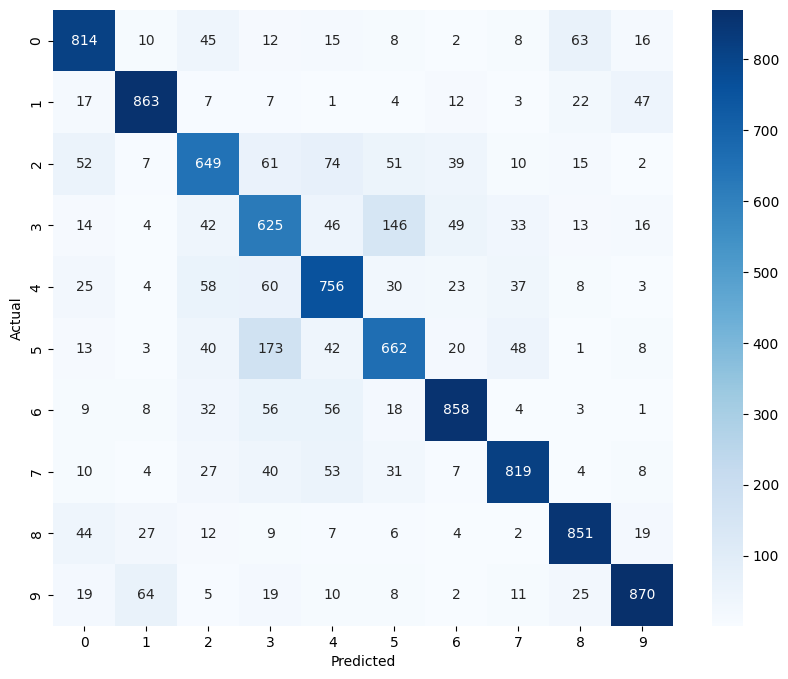

Save prediction data to ./out/prediction_20240415043020.csv


In [ ]:
svm_filename = generate_predict_data(pipe_svm, X_test, y_test, in_path='/kaggle/input/ass3-augmentation')

In [ ]:
!cat result.txt

############################################
filename: ./out/prediction_20240415043020.csv
accuracy: 0.7767
augmenters: [flip, shift_2, shift_up_2, Original]
features: [hog_9_(4, 4)_(2, 2)_2, hog_9_(6, 6)_(2, 2)_2, hog_9_(8, 8)_(2, 2)_2, hog_9_(10, 10)_(2, 2)_2, raw, haralick, color_histogram_256, sift]
Pipeline(steps=[('scaler', StandardScaler(copy=False)),
                ('pca', PCA(copy=False, n_components=0.88)),
                ('svm', SVC(C=10, cache_size=10000, random_state=42))],
         verbose=True)
############################################



In [ ]:
# # save model
# from joblib import dump

# def save_model(model, filename):
#     # generate model path according to the filename
#     model_path = filename.replace("out", "model").replace(".csv", ".joblib")

#     # check if folder exist
#     if not os.path.exists(model_path[:model_path.rfind("/")]):
#         os.makedirs(model_path[:model_path.rfind("/")])

#     dump(model, model_path)

In [ ]:
# save_model(pipe_svm, svm_filename)